In [31]:
import os
import cv2
import numpy as np
import torch
from torchvision import models, transforms
from numpy import dot
from numpy.linalg import norm
import matplotlib.pyplot as plt

In [32]:
DATASET_PATHS = ["Cattely-Augmented", "cow"]
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

TOP_K = 3
THRESHOLD = 0.75

In [33]:
device = "cuda" if torch .cuda.is_available() else "cpu"
print("Using device: "+ device)

Using device: cpu


In [34]:
def build_feature_extractor():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model = torch.nn.Sequential(*list(model.children())[:-1])
    model.to(device)
    model.eval()
    return model

feature_extractor = build_feature_extractor()

In [35]:
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [36]:
dataset_paths = ["Cattely-Augmented", "cow"]

def load_multiple_datasets(paths):
    all_cows = {}

    for dataset_path in paths:
        cows = load_cow_images(dataset_path)

        for cow_id, images in cows.items():
            if cow_id not in all_cows:
                all_cows[cow_id] = []
            
            all_cows[cow_id].extend(images)

    return all_cows

In [37]:
def load_cow_images(dataset_path):
    cows = {}

    if not os.path.exists(dataset_path):
        print(f"Warning: {dataset_path} not found")
        return cows

    for cow_id in sorted(os.listdir(dataset_path)):
        cow_dir = os.path.join(dataset_path, cow_id)

        if os.path.isdir(cow_dir):
            images = [
                os.path.join(cow_dir, f)
                for f in os.listdir(cow_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            if images:
                cows[cow_id] = sorted(images)

    return cows

In [38]:
cows = load_multiple_datasets(DATASET_PATHS)

print("Found cows:", list(cows.keys()))

print("\nDataset summary:")
for cow_id, images in cows.items():
    print(f"{cow_id}: {len(images)} images")

Found cows: ['n2005', 's114', 's1547', 's1556', 's1557', 's1607', 's1641', 's1706', 's1774', 's1778', 's1797', 's1804', 's1805', 's1806', 's1843', 's1853', 's1854', 's1868', 's1870', 's1877', 's1896', 's1903', 's1906', 's1914', 's1918', 's1935', 's2011', 's377', 's5562', 's7704', 's8803', 's8804', 's8813', 's8816', 's8819', 's8832', 's8835', 's8843', 'sn1125', 'sn13', 'sn15', 'sn1761', 'sn19', 'sn20', 'sn22', 'sn23']

Dataset summary:
n2005: 200 images
s114: 156 images
s1547: 200 images
s1556: 192 images
s1557: 108 images
s1607: 96 images
s1641: 100 images
s1706: 76 images
s1774: 148 images
s1778: 92 images
s1797: 200 images
s1804: 196 images
s1805: 200 images
s1806: 4 images
s1843: 108 images
s1853: 96 images
s1854: 64 images
s1868: 72 images
s1870: 40 images
s1877: 20 images
s1896: 112 images
s1903: 124 images
s1906: 84 images
s1914: 64 images
s1918: 16 images
s1935: 200 images
s2011: 104 images
s377: 140 images
s5562: 68 images
s7704: 72 images
s8803: 172 images
s8804: 108 images
s8

In [39]:
cows = load_multiple_datasets(DATASET_PATHS)

print("Found cows:", list(cows.keys()))

print("\nDataset summary:")
for cow_id, images in cows.items():
    print(f"{cow_id}: {len(images)} images")

Found cows: ['n2005', 's114', 's1547', 's1556', 's1557', 's1607', 's1641', 's1706', 's1774', 's1778', 's1797', 's1804', 's1805', 's1806', 's1843', 's1853', 's1854', 's1868', 's1870', 's1877', 's1896', 's1903', 's1906', 's1914', 's1918', 's1935', 's2011', 's377', 's5562', 's7704', 's8803', 's8804', 's8813', 's8816', 's8819', 's8832', 's8835', 's8843', 'sn1125', 'sn13', 'sn15', 'sn1761', 'sn19', 'sn20', 'sn22', 'sn23']

Dataset summary:
n2005: 200 images
s114: 156 images
s1547: 200 images
s1556: 192 images
s1557: 108 images
s1607: 96 images
s1641: 100 images
s1706: 76 images
s1774: 148 images
s1778: 92 images
s1797: 200 images
s1804: 196 images
s1805: 200 images
s1806: 4 images
s1843: 108 images
s1853: 96 images
s1854: 64 images
s1868: 72 images
s1870: 40 images
s1877: 20 images
s1896: 112 images
s1903: 124 images
s1906: 84 images
s1914: 64 images
s1918: 16 images
s1935: 200 images
s2011: 104 images
s377: 140 images
s5562: 68 images
s7704: 72 images
s8803: 172 images
s8804: 108 images
s8

In [40]:
def load_face(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Error loading {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [41]:
def build_embedding_database(cows):
    cow_embeddings = {}

    for cow_id, paths in cows.items():
        cow_embeddings[cow_id] = []

        for p in paths:
            try:
                img = load_face(p)
                emb = get_embedding(img)
                cow_embeddings[cow_id].append(emb)
            except:
                continue

    return cow_embeddings


def build_mean_embeddings(cow_embeddings):
    mean_db = {}

    for cow_id, embeddings in cow_embeddings.items():
        if len(embeddings) == 0:
            continue

        mean = np.mean(embeddings, axis=0)
        mean = mean / norm(mean)
        mean_db[cow_id] = mean

    return mean_db

In [42]:
def similarity(e1, e2):
    return float(dot(e1, e2))

In [43]:
def build_embedding_database(cows):
    cow_embeddings = {}

    for cow_id, paths in cows.items():
        cow_embeddings[cow_id] = []

        for p in paths:
            try:
                img = load_face(p)
                emb = get_embedding(img)
                cow_embeddings[cow_id].append(emb)
            except Exception as e:
                print(f"Skipping {p}: {e}")

    return cow_embeddings

In [44]:
print("Building embeddings...")
cow_embeddings = build_embedding_database(cows)
print("Embeddings complete.")

Building embeddings...
Embeddings complete.


In [45]:
def build_mean_embeddings(cow_embeddings):
    mean_db = {}

    for cow_id, embeddings in cow_embeddings.items():
        if len(embeddings) == 0:
            continue

        mean = np.mean(embeddings, axis=0)
        mean = mean / norm(mean)
        mean_db[cow_id] = mean

    return mean_db

In [46]:
mean_db = build_mean_embeddings(cow_embeddings)
print("Mean embedding database ready.")

Mean embedding database ready.


In [47]:
def identify_cow(query_path, mean_db):
    img = load_face(query_path)
    emb = get_embedding(img)

    results = []

    for cow_id, db_emb in mean_db.items():
        sim = similarity(emb, db_emb)
        results.append((cow_id, sim))

    results.sort(key=lambda x: x[1], reverse=True)

    best_id, best_score = results[0]

    if best_score < THRESHOLD:
        prediction = "UNKNOWN"
    else:
        prediction = best_id

    return img, prediction, best_score, results[:TOP_K]

In [48]:
def evaluate_model(cow_embeddings):
    TP = FP = TN = FN = 0
    cows_list = list(cow_embeddings.keys())

    for cow in cows_list:
        if len(cow_embeddings[cow]) < 2:
            continue

        e1 = cow_embeddings[cow][0]
        e2 = cow_embeddings[cow][1]

        same_score = similarity(e1, e2)

        if same_score >= THRESHOLD:
            TP += 1
        else:
            FN += 1

        other = cows_list[(cows_list.index(cow) + 1) % len(cows_list)]

        if len(cow_embeddings[other]) == 0:
            continue

        e_diff = cow_embeddings[other][0]
        diff_score = similarity(e1, e_diff)

        if diff_score < THRESHOLD:
            TN += 1
        else:
            FP += 1

    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0

    print("=== Evaluation Results ===")
    print("TP:", TP)
    print("TN:", TN)
    print("FP:", FP)
    print("FN:", FN)
    print("Accuracy:", round(accuracy, 4))

In [49]:
evaluate_model(cow_embeddings)

=== Evaluation Results ===
TP: 46
TN: 44
FP: 2
FN: 0
Accuracy: 0.9783


In [50]:
def show_image(img, title=""):
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

Query image: Cattely-Augmented\n2005\102_blur.jpg

Prediction: n2005
Score: 0.912

Top matches:
n2005: 0.9120
s1706: 0.6823
s8835: 0.6763


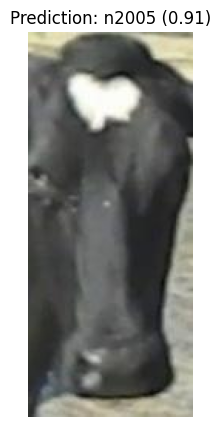

In [51]:
example_cow = list(cows.keys())[0]
query_path = cows[example_cow][0]

print("Query image:", query_path)

img, pred, score, results = identify_cow(query_path, mean_db)

print("\nPrediction:", pred)
print("Score:", round(score, 4))

print("\nTop matches:")
for cow_id, sim in results:
    print(f"{cow_id}: {sim:.4f}")

show_image(img, f"Prediction: {pred} ({score:.2f})")

In [52]:
cow_ids = list(cow_embeddings.keys())

cow1 = cow_ids[0]
cow2 = cow_ids[1]

same_sim = similarity(cow_embeddings[cow1][0], cow_embeddings[cow1][1])
diff_sim = similarity(cow_embeddings[cow1][0], cow_embeddings[cow2][0])

print(f"Same-cow similarity ({cow1}): {same_sim:.4f}")
print(f"Different-cow similarity ({cow1} vs {cow2}): {diff_sim:.4f}")

Same-cow similarity (n2005): 0.9666
Different-cow similarity (n2005 vs s114): 0.5581


In [53]:
def show_side_by_side(path1, path2, title1="", title2=""):
    img1 = load_face(path1)
    img2 = load_face(path2)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(title2)
    plt.axis("off")

    plt.show()

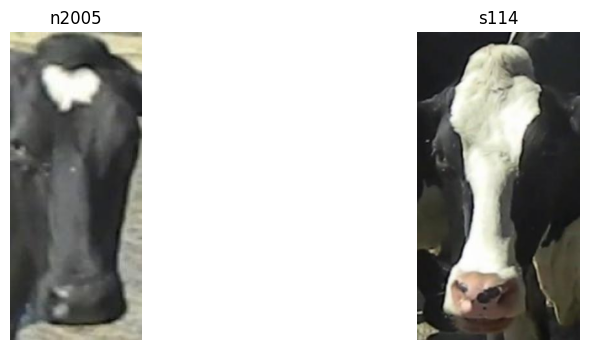

In [54]:
show_side_by_side(
    cows[cow1][0],
    cows[cow2][0],
    title1=cow1,
    title2=cow2
)